# 02 | Baseline retirement cash flow and estate review

This notebook establishes a common baseline for the decisions in Notebook 03. Elena and Marco retire in 2036, claim their illustrative benefits at age 67, and hold planned spending at $145,000 in 2026 dollars. Annual returns are fixed at 5% nominal and inflation at 2.5%. The model is deterministic, not a probability-of-success forecast. Withdrawals precede investment returns. The 18% reserve on portfolio withdrawals is a tax planning proxy, not an account-level tax calculation.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()))
import pandas as pd
import matplotlib.pyplot as plt
from financial_plan import Assumptions, project, summary

a = Assumptions()
base = pd.DataFrame(project(a))
report = summary(base.to_dict('records'))
display(pd.Series(report, name='Baseline result').to_frame())
print(f"2066 portfolio: ${report['age_95_portfolio_real']:,.0f} in 2026 purchasing power")

,Baseline result
retirement_year,2.036000e+03
retirement_portfolio,3.901572e+06
first_year_withdrawal,2.263564e+05
first_year_rate,5.801672e-02
age_95_portfolio,5.696259e+06
age_95_portfolio_real,2.121461e+06
lowest_retirement_balance_real,2.121461e+06
total_spending_cuts_real,0.000000e+00
total_care_cost_real,0.000000e+00
first_shortfall_year,NaN


2066 portfolio: $2,121,461 in 2026 purchasing power


## Where the retirement paycheck comes from

The first two retirement years precede both Social Security benefits. Elena begins her modeled benefit in 2038 and Marco in 2040. The annual withdrawal is the spending gap divided by 0.82 to allow an illustrative 18% tax reserve. The portfolio never uses the separate $100,000 emergency cash or home equity.

,year,age_a,age_b,opening,spending,social_security,portfolio_withdrawal,withdrawal_rate,ending
9,2035,64,62,"$3,641,801",$0,$0,$0,0.0%,"$3,901,572"
10,2036,65,63,"$3,901,572","$185,612",$0,"$226,356",5.8%,"$3,858,977"
11,2037,66,64,"$3,858,977","$190,253",$0,"$232,015",6.0%,"$3,808,309"
12,2038,67,65,"$3,808,309","$195,009","$61,865","$162,371",4.3%,"$3,828,235"
13,2039,68,66,"$3,828,235","$199,884","$63,412","$166,430",4.3%,"$3,844,896"
14,2040,69,67,"$3,844,896","$204,881","$110,212","$115,450",3.0%,"$3,915,918"
15,2041,70,68,"$3,915,918","$210,003","$112,967","$118,337",3.0%,"$3,987,460"
16,2042,71,69,"$3,987,460","$215,253","$115,791","$121,295",3.0%,"$4,059,474"


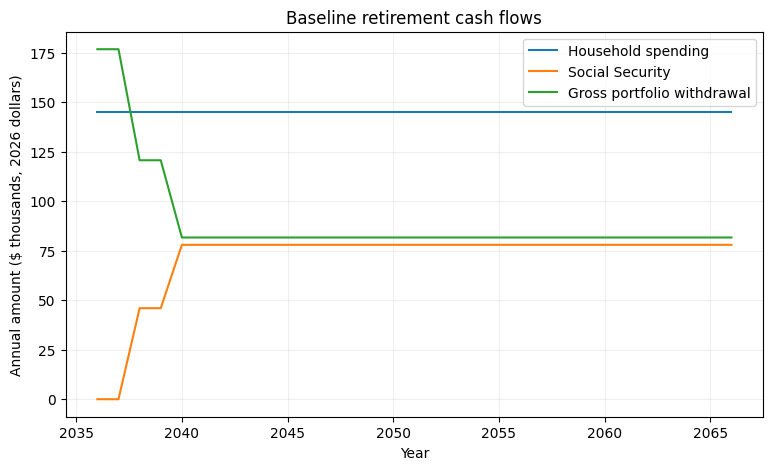

In [2]:
display(base.loc[base.year.between(2035, 2042),
                 ['year','age_a','age_b','opening','spending','social_security','portfolio_withdrawal','withdrawal_rate','ending']]
        .style.format({'opening':'${:,.0f}','spending':'${:,.0f}',
                       'social_security':'${:,.0f}','portfolio_withdrawal':'${:,.0f}',
                       'withdrawal_rate':'{:.1%}','ending':'${:,.0f}'}))
ret = base[base.retired]
fig, ax = plt.subplots(figsize=(9, 5))
for column, label in [('spending','Household spending'), ('social_security','Social Security'),
                      ('portfolio_withdrawal','Gross portfolio withdrawal')]:
    ax.plot(ret.year, ret[column] / ret.price_index / 1000, label=label)
ax.set(xlabel='Year', ylabel='Annual amount ($ thousands, 2026 dollars)',
       title='Baseline retirement cash flows')
ax.legend(); ax.grid(alpha=.2); plt.show()

## Advisory interpretation

The initial 5.8% withdrawal rate warrants review because it occurs before Social Security income begins. The [Morningstar 2025 retirement-income study](https://www.morningstar.com/content/cs-assets/v3/assets/blt9415ea4cc4157833/bltb73b87c5d0c70ead/The_State_of_Retirement_Income_2025.pdf) reports a 3.9% starting reference under its own 30-year assumptions. It is not a pass/fail test for this household. Notebook 03 compares actions the couple could take.

## Estate and implementation checklist

1. Reconcile wills or a trust with account beneficiaries, contingent beneficiaries, and property titles.
2. Review durable financial and health-care powers of attorney and advance directives with qualified counsel. [CFPB guidance](https://www.consumerfinance.gov/ask-cfpb/what-is-a-power-of-attorney-poa-en-1149/).
3. Price survivor, life, disability, and long-term-care protection; test a single-survivor budget in Notebook 03.
4. Review Roth conversions, withdrawal order, and RMD timing with a tax professional. [IRS RMD guidance](https://www.irs.gov/retirement-plans/retirement-plan-and-ira-required-minimum-distributions-faqs).
5. The [2026 federal estate basic exclusion is $15 million per person](https://www.irs.gov/instructions/i706), above the fictional current net worth. State-specific law and document execution still matter.

The baseline omits fees, return volatility, account-level taxes, Medicare premiums, and changes in law.